In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('../data/cleaned/cleaned.csv')

In [ ]:
# basic info
print(df.shape)
print(df.info())

(148835, 14)
<class 'pandas.DataFrame'>
RangeIndex: 148835 entries, 0 to 148834
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_Type     148835 non-null  str    
 1   Target_Audience   148835 non-null  str    
 2   Duration          148835 non-null  int64  
 3   Channel_Used      148835 non-null  str    
 4   Impressions       148835 non-null  float64
 5   Clicks            148835 non-null  int64  
 6   Leads             148835 non-null  float64
 7   Conversions       148835 non-null  int64  
 8   Revenue           148835 non-null  int64  
 9   Acquisition_Cost  148835 non-null  float64
 10  ROI               148835 non-null  float64
 11  Engagement_Score  148835 non-null  int64  
 12  Customer_Segment  148835 non-null  str    
 13  Total_Cost        148835 non-null  float64
dtypes: float64(5), int64(5), str(4)
memory usage: 15.9 MB
None


In [ ]:
# summary stats
df.describe()

,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score,Total_Cost
count,148835.000000,148835.000000,148835.00000,148835.000000,148835.000000,1.488350e+05,148835.000000,148835.000000,148835.000000,148835.000000
mean,17.492082,54811.380912,4629.70349,1829.296641,990.862969,4.826193e+05,310.181319,2.227886,13.706742,167058.329879
std,7.315919,25853.492771,3066.69242,1331.071719,754.904802,3.933007e+05,267.260387,2.808198,6.167784,71857.419864
min,5.000000,10001.000000,202.00000,48.000000,17.000000,3.895000e+03,8.180000,-0.860000,3.000000,15479.647500
25%,11.000000,32402.000000,2123.00000,778.000000,400.000000,1.777620e+05,107.700000,0.040000,9.000000,105561.255000
50%,17.000000,54840.000000,3921.00000,1470.000000,772.000000,3.579010e+05,209.830000,1.220000,14.000000,163082.480000
75%,24.000000,77222.500000,6619.00000,2574.000000,1390.000000,6.794140e+05,429.830000,3.570000,18.000000,226131.875000
max,30.000000,100000.000000,13501.00000,5329.500000,2912.000000,1.448850e+06,910.567500,8.910000,31.000000,424006.160000


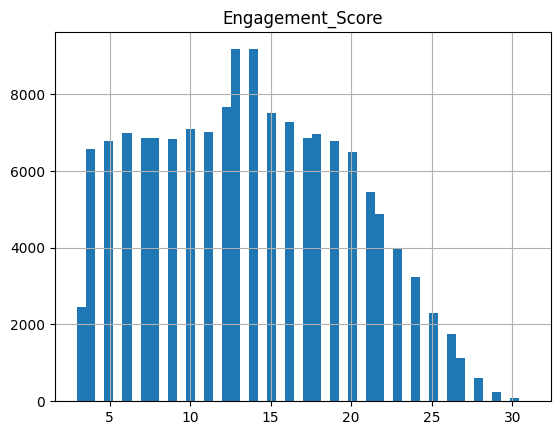

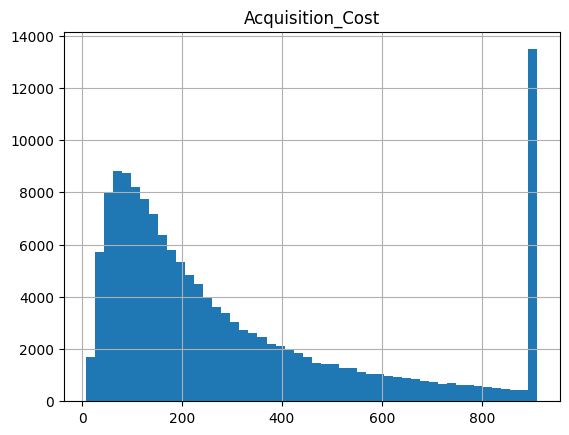

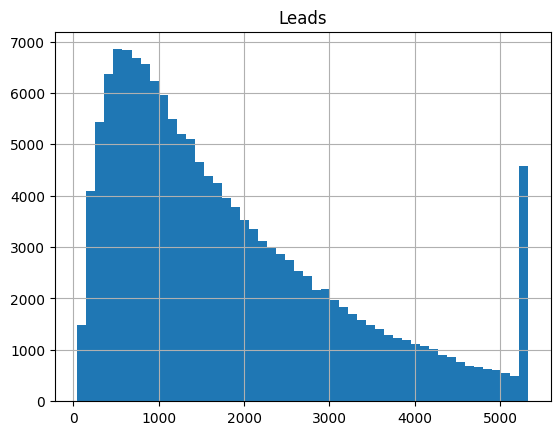

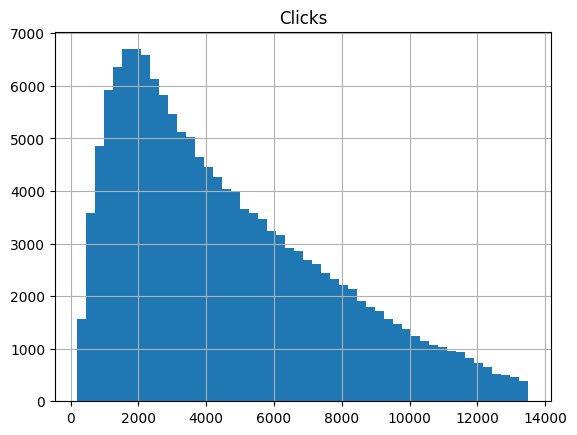

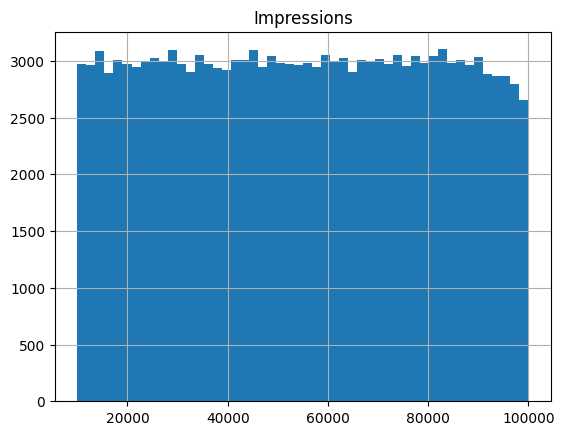

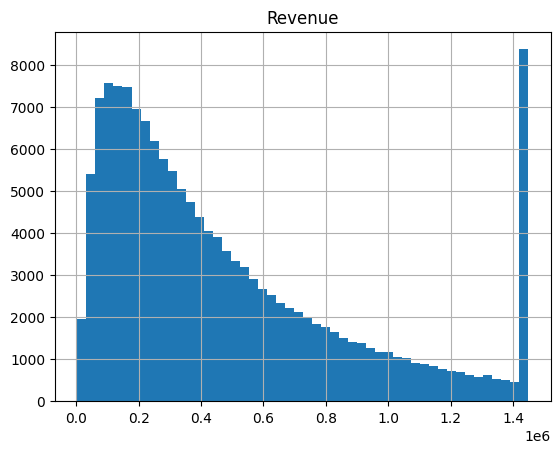

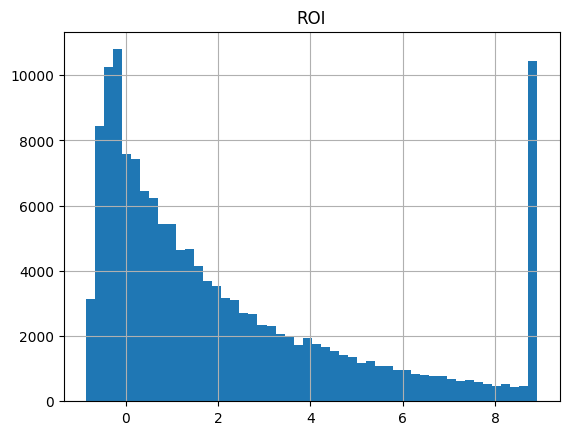

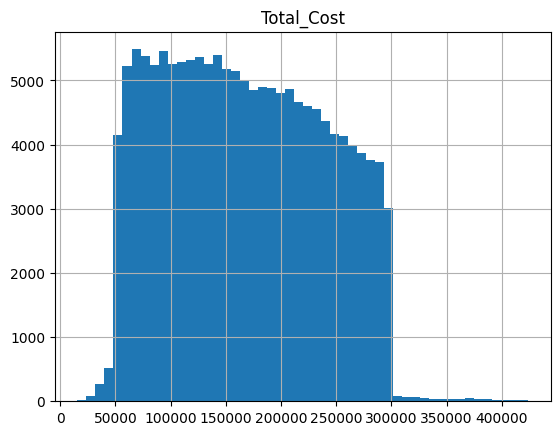

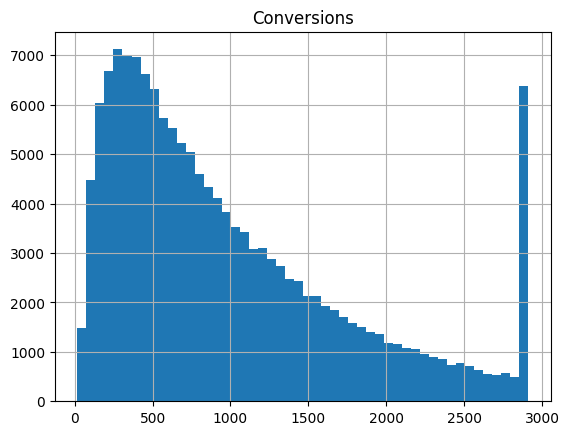

In [ ]:
# check distributions

cols = ["Engagement_Score", "Acquisition_Cost", "Leads", "Clicks", "Impressions", "Revenue", "ROI", "Total_Cost", "Conversions"]

for col in cols:
    plt.figure()
    df[col].hist(bins=50)
    plt.title(col)
    plt.show()


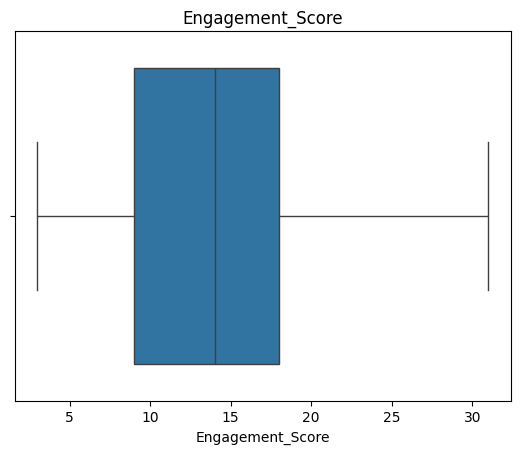

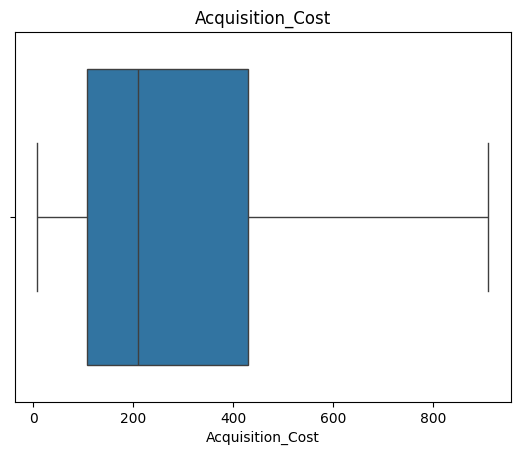

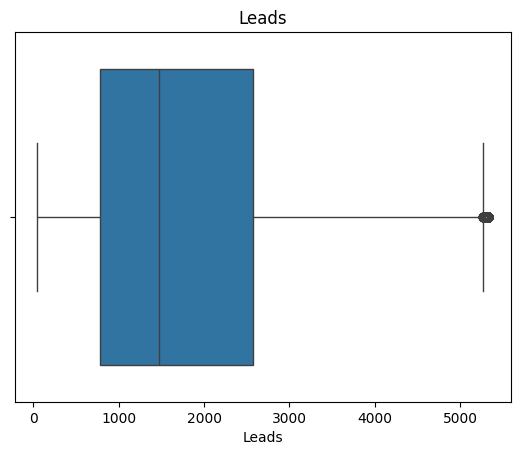

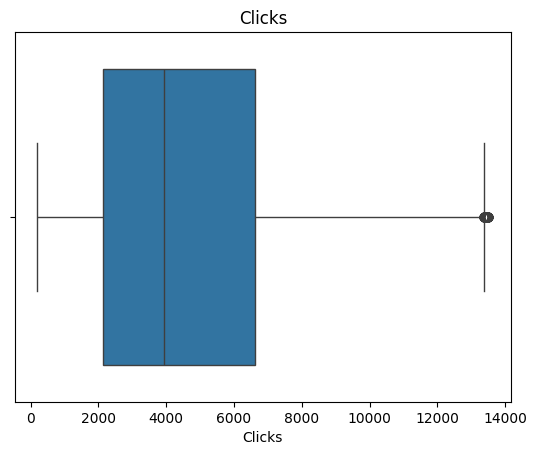

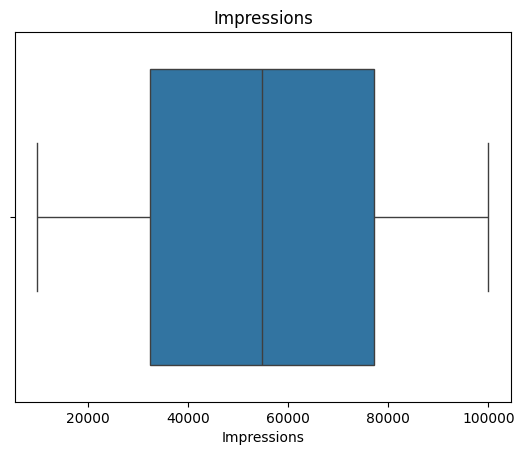

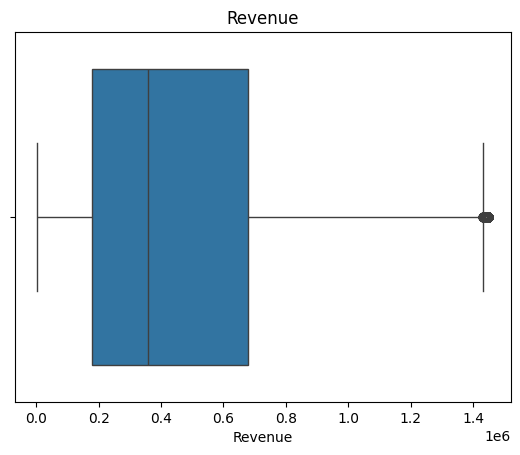

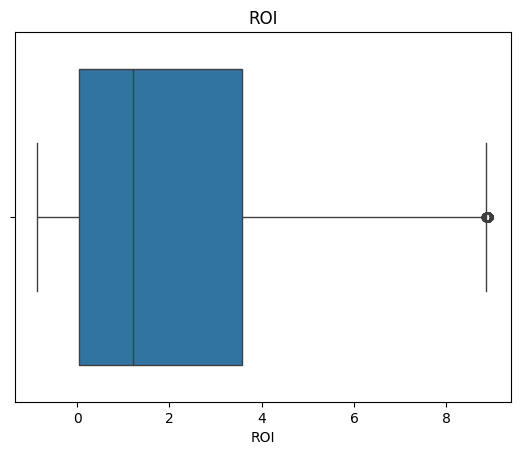

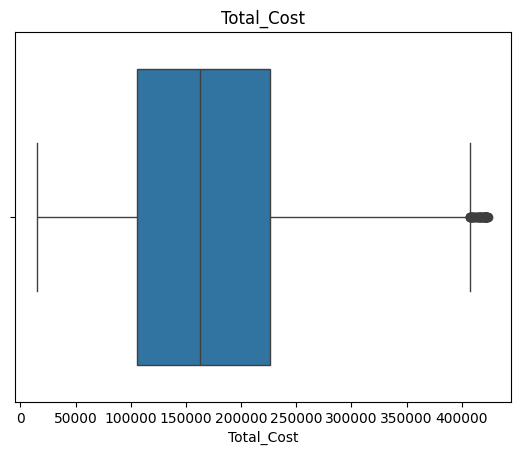

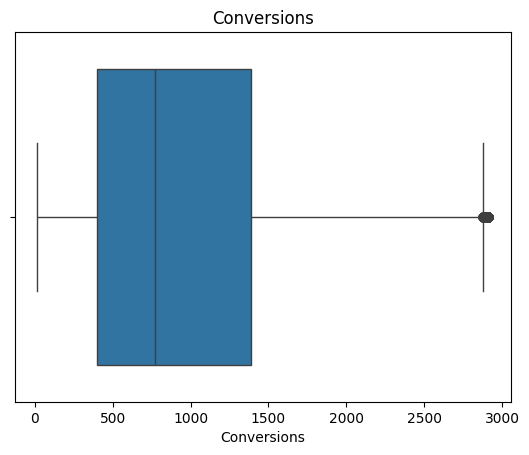

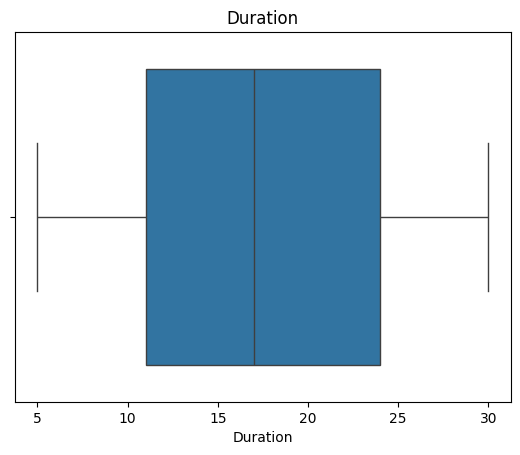

In [ ]:
for col in cols + ["Duration"]:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
# ROI and Revenue by Brand
brand_perf = df.groupby("Brand").agg({
    "ROI": "median",
    "Revenue": "median",
    "Conversions": "median"
}).sort_values(by="ROI", ascending=False)

print(brand_perf)


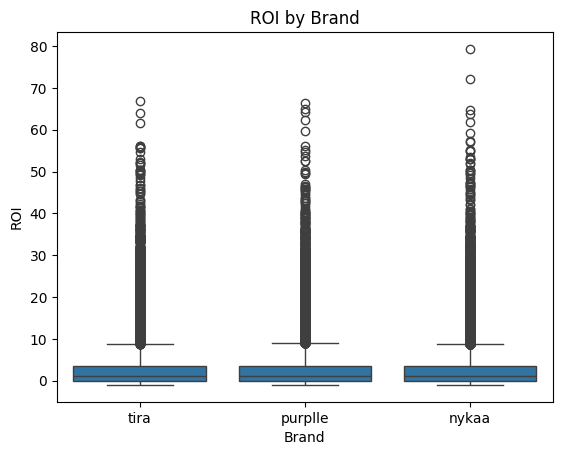

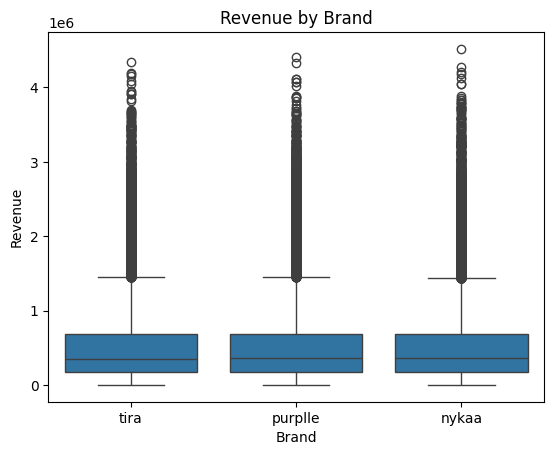

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ROI by Brand
sns.boxplot(x="Brand", y="ROI", data=df)
plt.title("ROI by Brand")
plt.show()

# Revenue by Brand
sns.boxplot(x="Brand", y="Revenue", data=df)
plt.title("Revenue by Brand")
plt.show()


In [ ]:
# Top campaigns
top_campaigns = df.sort_values(by="ROI", ascending=False).head(10)
print(top_campaigns[["Campaign_Type", "Channel_Used", "ROI", "Revenue"]])

# Worst campaigns
low_campaigns = df.sort_values(by="ROI", ascending=True).head(10)
print(low_campaigns[["Campaign_Type", "Channel_Used", "ROI", "Revenue"]])


       Campaign_Type                 Channel_Used   ROI  Revenue
148786           seo            facebook, youtube  8.91  1448850
148797      paid ads    facebook, email, whatsapp  8.91   795130
65             email                      youtube  8.91  1208020
64             email                       google  8.91  1226856
27548     influencer          facebook, instagram  8.91  1040094
27550     influencer     youtube, facebook, email  8.91   541296
95670     influencer              youtube, google  8.91  1448850
95649     influencer           facebook, whatsapp  8.91  1448850
95705          email  whatsapp, facebook, youtube  8.91  1313500
95690            seo  whatsapp, facebook, youtube  8.91  1448850
       Campaign_Type                 Channel_Used   ROI  Revenue
69382     influencer                       google -0.86    34704
86571     influencer  facebook, google, instagram -0.85    32175
13793          email          instagram, whatsapp -0.85    17472
58832   social media     

In [ ]:
group_perf = df.groupby(
    ["Campaign_Type", "Channel_Used"]
)["ROI"].median().sort_values(ascending=False)

print(group_perf.head(10))   # best combos
print(group_perf.tail(10))   # worst combos


Campaign_Type  Channel_Used               
social media   google, youtube, email         2.640
email          youtube, instagram, email      2.560
               youtube, whatsapp, facebook    2.400
social media   google, youtube, facebook      2.310
paid ads       email, instagram, whatsapp     2.310
social media   google, email, youtube         2.190
               youtube, instagram, email      2.170
seo            email, facebook, whatsapp      2.160
paid ads       youtube, instagram, email      2.150
seo            youtube, whatsapp, email       2.145
Name: ROI, dtype: float64
Campaign_Type  Channel_Used               
influencer     youtube, google, whatsapp      0.620
social media   facebook, whatsapp, google     0.610
               instagram, youtube, email      0.600
seo            youtube, facebook, email       0.600
influencer     facebook, email, youtube       0.570
social media   whatsapp, google, instagram    0.535
email          google, whatsapp, facebook     0.530
    

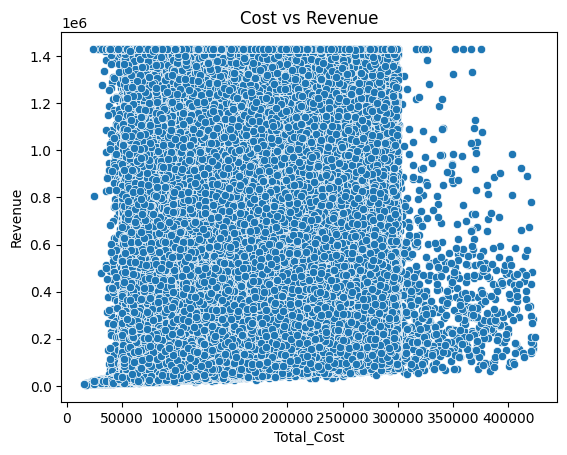

In [ ]:
# Cost vs Revenue
sns.scatterplot(x="Total_Cost", y="Revenue", data=df)
plt.title("Cost vs Revenue")
plt.show()

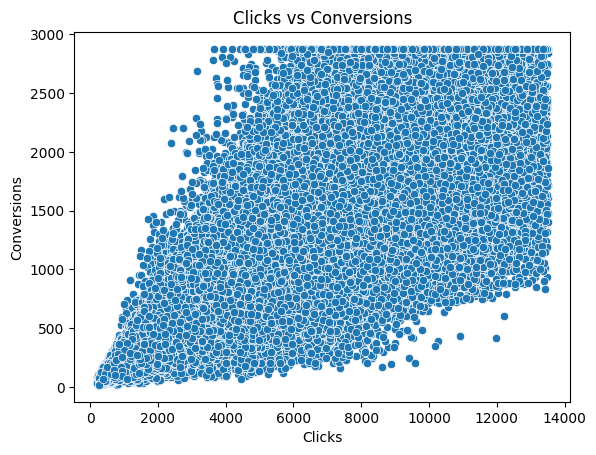

In [ ]:
# Clicks vs Conversions
sns.scatterplot(x="Clicks", y="Conversions", data=df)
plt.title("Clicks vs Conversions")
plt.show()

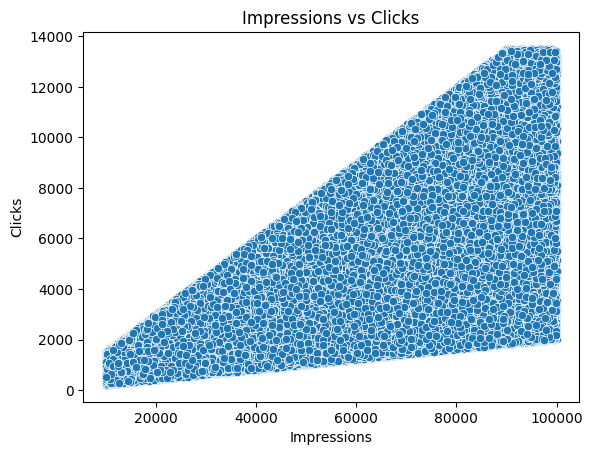

In [ ]:
# Impressions vs Clicks
sns.scatterplot(x="Impressions", y="Clicks", data=df)
plt.title("Impressions vs Clicks")
plt.show()

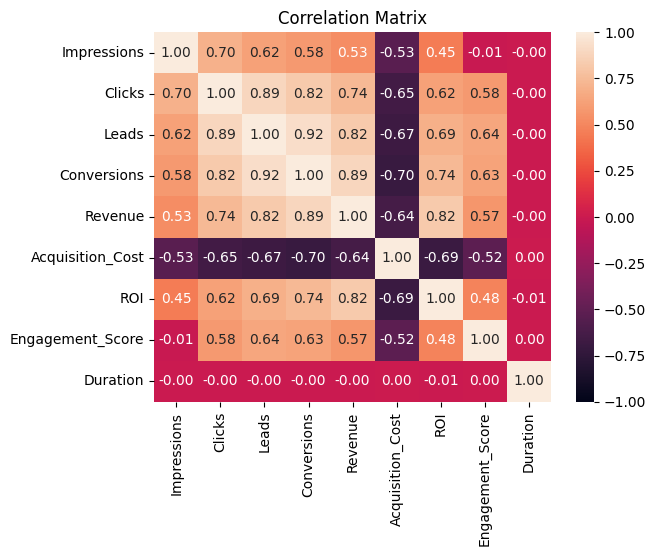

In [ ]:
corr = df[[
    "Impressions","Clicks","Leads","Conversions",
    "Revenue","Acquisition_Cost","ROI", "Engagement_Score", "Duration"
]].corr()

sns.heatmap(corr, annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()


In [ ]:
channel_perf = df.groupby("Channel_Used").agg({
    "ROI": "median",
    "Revenue": "median",
    "Conversions": "median"
}).sort_values(by="ROI", ascending=False)

print(channel_perf)


                                 ROI   Revenue  Conversions
Channel_Used                                               
instagram, facebook, whatsapp  1.540  372280.0        773.0
google, youtube, email         1.535  382311.5        840.0
google, facebook, youtube      1.520  347072.0        757.0
youtube, instagram, email      1.515  415762.0        841.0
whatsapp, email, google        1.500  385530.0        768.0
...                              ...       ...          ...
email, whatsapp, google        0.990  326831.0        775.0
whatsapp, google, instagram    0.970  338422.0        701.0
whatsapp, email, youtube       0.950  330982.5        713.0
whatsapp, youtube, google      0.910  326606.0        720.0
email, youtube, instagram      0.860  320814.0        700.0

[156 rows x 3 columns]


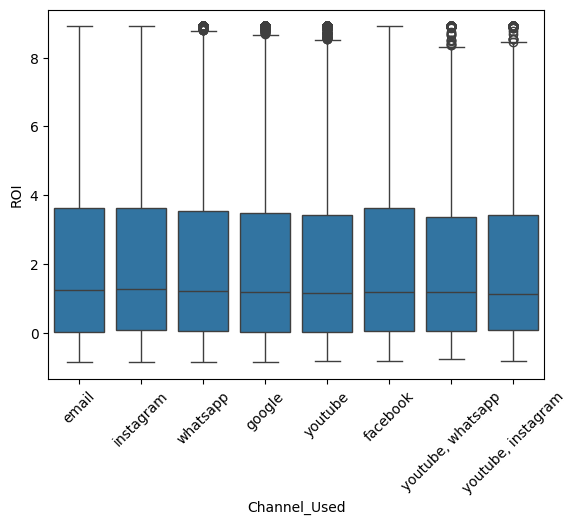

In [ ]:
top_channels = df["Channel_Used"].value_counts().nlargest(8).index

df_top = df[df["Channel_Used"].isin(top_channels)]

sns.boxplot(x="Channel_Used", y="ROI", data=df_top)
plt.xticks(rotation=45)
plt.show()


In [ ]:
combo_perf = df.groupby(
    ["Campaign_Type", "Channel_Used"]
).agg({
    "ROI": "median",
    "Revenue": "median",
    "Conversions": "median"
}).sort_values(by="ROI", ascending=False)

print(combo_perf.head(10))   # top strategies


                                             ROI   Revenue  Conversions
Campaign_Type Channel_Used                                             
social media  google, youtube, email       2.640  490323.0       1048.5
email         youtube, instagram, email    2.560  477333.0       1117.0
              youtube, whatsapp, facebook  2.400  448470.0        958.0
social media  google, youtube, facebook    2.310  461264.0       1047.0
paid ads      email, instagram, whatsapp   2.310  510431.0       1074.0
social media  google, email, youtube       2.190  448298.0        949.0
              youtube, instagram, email    2.170  399734.0        739.0
seo           email, facebook, whatsapp    2.160  412890.0        866.5
paid ads      youtube, instagram, email    2.150  413083.0        972.0
seo           youtube, whatsapp, email     2.145  430403.0        957.0


In [ ]:
print(combo_perf.tail(10))

                                             ROI   Revenue  Conversions
Campaign_Type Channel_Used                                             
influencer    youtube, google, whatsapp    0.620  280530.0        612.5
social media  facebook, whatsapp, google   0.610  299250.0        886.0
              instagram, youtube, email    0.600  290601.0        621.0
seo           youtube, facebook, email     0.600  355198.0        590.0
influencer    facebook, email, youtube     0.570  332760.0        682.0
social media  whatsapp, google, instagram  0.535  262858.0        518.0
email         google, whatsapp, facebook   0.530  288623.0        667.0
              email, youtube, instagram    0.510  209374.0        595.0
paid ads      whatsapp, youtube, google    0.480  289250.0        562.0
seo           youtube, whatsapp, facebook  0.425  253101.5        554.0


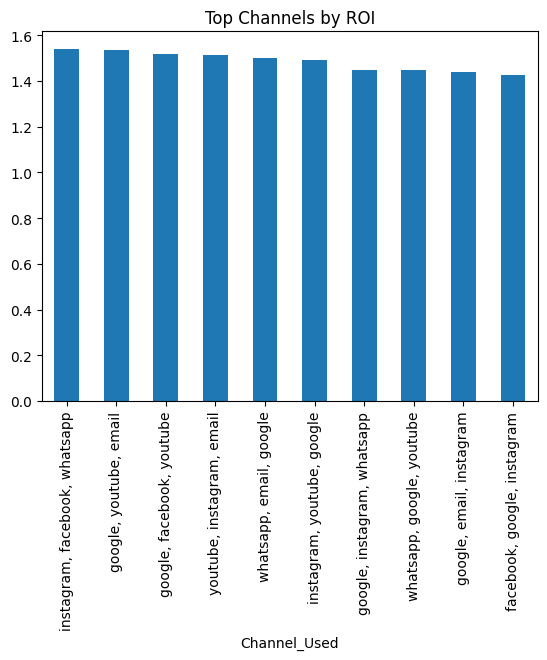

In [ ]:
channel_perf = df.groupby("Channel_Used")["ROI"].median().sort_values(ascending=False)

channel_perf.head(10).plot(kind="bar")
plt.title("Top Channels by ROI")
plt.show()
